# DS-Pool Kinetic Model — Refinement Pass (widened n bound)

Follow-up to `DS_Pool_Kinetic_Model.ipynb`. That run found strong evidence
(&Delta;AIC = -64.1, decisive) that freeing n and m beats first-order kinetics in
the DS-pool representation — but n came back pinned at its lower bound
(0.1187, right against the `(0.1, 4.0)` fence), which means that specific value
isn't trustworthy, only the *direction* (n far below 1) is.

**What this notebook does differently:**
1. Widens n's lower bound from 0.1 to **-0.5**, so the optimizer isn't artificially
   fenced in.
2. **Warm-starts from the previous result** (k1-k6, n=0.1187, m=1.8915) instead of
   restarting from the n=m=1 baseline — this refines a known-good region instead of
   re-searching from scratch, which should converge faster than the ~74 min the
   original free-n,m run took.
3. Flags explicitly if n pins again at -0.5 — if it does, that's the signal to stop
   pushing the power-law order down and switch to a saturation-type
   (Michaelis-Menten-style) rate law instead, since an increasingly negative order
   stops being physically interpretable.

**Previous result (for reference / used as the warm start below):**
```
Refined SSE (n,m free): 3.3868   [4419.1s]
Fitted n = 0.1187, m = 1.8915
k1(desb30->detemir)     : 4.8247e+03
k2(desb30->other_DS1)   : 1.1349e+03
k3(detemir->DS2)        : 1.7717e+02
k4(other_DS1->DS2)      : 1.3710e+04
k5(DS2->DS3)            : 2.1149e+03
k6(hydro)               : 1.2584e-01
```

**Runtime note:** the extreme-n region needs smaller internal steps from the
Radau stiff solver, which is why the previous run took ~74 min instead of the
~10 min originally estimated. Widening the bound further may push n lower still,
so budget similarly — or reduce `maxiter` for this pass since you're refining
from a known-good point, not searching blind.

## 1. Imports

In [1]:
import time, functools
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import minimize, differential_evolution
from sklearn.metrics import mean_squared_error, r2_score

print = functools.partial(print, flush=True)


## 2. Data loading + DS-pool aggregation (identical to the original DS-pool notebook)

In [2]:
MW = {
    'desb30': 5706.524,
    'DS1': 5916.885,   # shared by A1, B1, detemir
    'DS2': 6127.246,   # shared by A1_B1, A1_B29, B1_B29
    'DS3': 6337.607,   # A1_B29_B1
    'nhs_myr': 325.449, 'nhs': 115.088
}

DS1_PEAKS = ['A1', 'B1', 'detemir']     # confirmed: detemir. unconfirmed: A1, B1
DS2_PEAKS = ['A1_B1', 'A1_B29', 'B1_B29']
DS3_PEAKS = ['A1_B29_B1']

df = pd.read_csv('kinetic_data_processed.csv')
df['Time'] = df['Time'].astype(float)
df['Perbandingan'] = df['Perbandingan'].astype(float)

ratios = sorted(df['Perbandingan'].unique())
time_points = sorted(df['Time'].unique())
time_exp = np.sort(df['Time'].unique())

def get_gL_series(df_ratio, peak_name):
    sub = df_ratio[df_ratio['Peak Identification'] == peak_name].sort_values('Time')
    return sub.set_index('Time')['Conc'].reindex(time_points, fill_value=0.0).values

experimental_dataset = {}
for r in ratios:
    df_ratio = df[df['Perbandingan'] == r]
    desb30_gL = get_gL_series(df_ratio, 'desb30')
    detemir_gL = get_gL_series(df_ratio, 'detemir')
    other_ds1_gL = get_gL_series(df_ratio, 'A1') + get_gL_series(df_ratio, 'B1')
    ds2_gL = sum(get_gL_series(df_ratio, p) for p in DS2_PEAKS)
    ds3_gL = get_gL_series(df_ratio, 'A1_B29_B1')

    experimental_dataset[r] = {
        'desb30': desb30_gL / MW['desb30'],
        'detemir': detemir_gL / MW['DS1'],
        'other_DS1': other_ds1_gL / MW['DS1'],
        'DS2_total': ds2_gL / MW['DS2'],
        'DS3': ds3_gL / MW['DS3'],
    }

pool_species_list = ['desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3']

N_DATAPOINTS = 0
for r in ratios:
    for sp in pool_species_list:
        vals_gL = experimental_dataset[r][sp] * MW['desb30' if sp == 'desb30' else
                                                    ('DS1' if sp in ('detemir', 'other_DS1') else
                                                     ('DS2' if sp == 'DS2_total' else 'DS3'))]
        N_DATAPOINTS += int(np.sum(~np.isnan(vals_gL) & (vals_gL > 1e-6)))
print(f"Total usable data points (DS-pool representation): {N_DATAPOINTS}")
print(f"Ratios: {ratios}")


Total usable data points (DS-pool representation): 274
Ratios: [1.0, 1.5, 2.0]


## 3. The model (identical to the original DS-pool notebook)

In [3]:
class DSPoolKineticModel:
    species = ['nhs_myr', 'desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3']
    idx = {name: i for i, name in enumerate(species)}

    def __init__(self, params):
        self.k = params[:6]   # k1..k6 (k6 = hydrolysis)
        self.n = params[6]
        self.m = params[7]

    def _ode_system(self, t, y):
        y_safe = np.maximum(y, 1e-12)
        idx = self.idx
        C_nhsm = y_safe[idx['nhs_myr']]
        C_desb = y_safe[idx['desb30']]
        C_det = y_safe[idx['detemir']]
        C_oDS1 = y_safe[idx['other_DS1']]
        C_DS2 = y_safe[idx['DS2_total']]

        r1 = self.k[0] * (C_nhsm ** self.n) * (C_desb ** self.m)   # desb30 -> detemir
        r2 = self.k[1] * (C_nhsm ** self.n) * (C_desb ** self.m)   # desb30 -> other_DS1
        r3 = self.k[2] * (C_nhsm ** self.n) * (C_det ** self.m)    # detemir -> DS2
        r4 = self.k[3] * (C_nhsm ** self.n) * (C_oDS1 ** self.m)   # other_DS1 -> DS2
        r5 = self.k[4] * (C_nhsm ** self.n) * (C_DS2 ** self.m)    # DS2 -> DS3
        r_hydro = self.k[5] * C_nhsm

        dydt = np.zeros_like(y)
        dydt[idx['nhs_myr']] = -(r1 + r2 + r3 + r4 + r5) - r_hydro
        dydt[idx['desb30']] = -(r1 + r2)
        dydt[idx['detemir']] = r1 - r3
        dydt[idx['other_DS1']] = r2 - r4
        dydt[idx['DS2_total']] = r3 + r4 - r5
        dydt[idx['DS3']] = r5
        return dydt

    def simulate(self, y0, t_span, t_eval):
        return solve_ivp(self._ode_system, t_span, y0, t_eval=np.sort(t_eval),
                          method='Radau', atol=1e-9, rtol=1e-7)


## 4. Objective function (identical to the original DS-pool notebook)

In [4]:
weights = {
    'desb30': 2.0,
    'detemir': 3.0,       # this is the confirmed, business-relevant target
    'other_DS1': 0.75,
    'DS2_total': 0.75,
    'DS3': 0.5,
}
MASS_BALANCE_PENALTY_WEIGHT = 1e6

pool_mw = {'desb30': MW['desb30'], 'detemir': MW['DS1'], 'other_DS1': MW['DS1'],
           'DS2_total': MW['DS2'], 'DS3': MW['DS3']}

def objective_function_pool(params):
    k_vals = np.exp(params[:6])
    n, m = params[6], params[7]

    if np.any(k_vals > 1e8):
        return 1e12

    model = DSPoolKineticModel(list(k_vals) + [n, m])
    total_sse = 0.0

    for r in ratios:
        desb30_t0 = experimental_dataset[r]['desb30'][0]
        y0 = np.zeros(len(model.species))
        y0[model.idx['nhs_myr']] = desb30_t0 * r
        y0[model.idx['desb30']] = desb30_t0

        sol = model.simulate(y0, (0, 120), time_exp)
        if not sol.success or np.any(np.isnan(sol.y)) or np.any(np.isinf(sol.y)):
            return 1e12

        moles_in = desb30_t0
        moles_out = np.sum([sol.y[model.idx[sp]][-1] for sp in model.species if sp != 'nhs_myr'])
        rel_drift = abs(moles_in - moles_out) / moles_in
        total_sse += MASS_BALANCE_PENALTY_WEIGHT * rel_drift ** 2

        for sp in pool_species_list:
            sim_vals = sol.y[model.idx[sp]] * pool_mw[sp]
            exp_vals = experimental_dataset[r][sp] * pool_mw[sp]
            mask = ~np.isnan(exp_vals) & (exp_vals > 1e-6)
            if np.any(mask):
                err = sim_vals[mask] - exp_vals[mask]
                total_sse += np.sum((err * weights[sp]) ** 2)

    return total_sse


## 5. Previous result (hardcoded, used as the warm start)

This is the fit you already ran — reproduced here so the refinement pass starts
from it instead of from the n=m=1 baseline.

In [5]:
PREVIOUS_SSE = 3.3868
PREVIOUS_K_VALS = np.array([
    4.8247e+03,   # k1 (desb30 -> detemir)
    1.1349e+03,   # k2 (desb30 -> other_DS1)
    1.7717e+02,   # k3 (detemir -> DS2)
    1.3710e+04,   # k4 (other_DS1 -> DS2)
    2.1149e+03,   # k5 (DS2 -> DS3)
    1.2584e-01,   # k6 (hydrolysis)
])
PREVIOUS_N = 0.1187
PREVIOUS_M = 1.8915

# baseline (n=m=1) result from the SAME earlier run, needed for the AIC/BIC table below
BASELINE_SSE = 4.3427


## 6. Refinement fit driver

Widens n's lower bound to -0.5 and builds the DE initial population centered on
the previous result (with a smaller perturbation than a cold start would use,
since we're refining, not exploring blind).

In [6]:
def fit_refined(popsize=25, maxiter=100, workers=4, seed=7,
                 n_lower_bound=-0.5, perturb_scale=0.15):
    bounds_k_only = [(np.log(1e-6), np.log(1e7))] * 6
    n_m_bounds = [(n_lower_bound, 4.0), (0.1, 4.0)]
    bounds_full = bounds_k_only + n_m_bounds

    rng = np.random.default_rng(seed)
    n_dims = len(bounds_full)
    pop_size = popsize * n_dims

    init_center = np.concatenate([np.log(PREVIOUS_K_VALS), [PREVIOUS_N, PREVIOUS_M]])
    init_pop = np.tile(init_center, (pop_size, 1))
    lo = np.array([b[0] for b in bounds_full]); hi = np.array([b[1] for b in bounds_full])
    noise = rng.normal(scale=perturb_scale, size=init_pop.shape)
    init_pop[1:] += noise[1:]
    init_pop = np.clip(init_pop, lo, hi)

    print(f"\nRefinement fit: n bound widened to ({n_lower_bound}, 4.0), warm-started from previous result...")
    t0 = time.time()
    res_de = differential_evolution(
        objective_function_pool, bounds_full,
        popsize=popsize, maxiter=maxiter, mutation=(0.5, 1.5),
        recombination=0.7, workers=workers, updating='deferred', seed=seed, init=init_pop
    )
    res_final = minimize(
        objective_function_pool, res_de.x, method='L-BFGS-B',
        bounds=bounds_full, options={'ftol': 1e-9, 'maxiter': 1000}
    )
    dt = time.time() - t0
    print(f"Refined SSE: {res_final.fun:.4f}   [{dt:.1f}s]")
    print(f"Fitted n = {res_final.x[6]:.4f}, m = {res_final.x[7]:.4f}")
    print(f"(previous:  n = {PREVIOUS_N:.4f}, m = {PREVIOUS_M:.4f}, SSE = {PREVIOUS_SSE:.4f})")

    # AIC/BIC: baseline vs previous free-n,m vs this refinement
    print("\n--- AIC/BIC comparison ---")
    for label, sse, k_params in [('baseline (n=m=1)', BASELINE_SSE, 6),
                                  ('previous free n,m (n pinned)', PREVIOUS_SSE, 8),
                                  ('refined free n,m (wider bound)', res_final.fun, 8)]:
        aic = 2 * k_params + N_DATAPOINTS * np.log(sse / N_DATAPOINTS)
        bic = k_params * np.log(N_DATAPOINTS) + N_DATAPOINTS * np.log(sse / N_DATAPOINTS)
        print(f"  [{label:32}] SSE={sse:.4f} AIC={aic:.2f} BIC={bic:.2f}")

    # boundary check - the important one this time
    print("\n--- Boundary check ---")
    names = ['k1(desb30->detemir)', 'k2(desb30->other_DS1)', 'k3(detemir->DS2)',
             'k4(other_DS1->DS2)', 'k5(DS2->DS3)', 'k6(hydro)', 'n', 'm']
    pinned_n_again = False
    for name, val, (blo, bhi) in zip(names, res_final.x, bounds_full):
        span = bhi - blo
        if span > 0 and (val - blo) / span < 0.02:
            print(f"  WARNING: {name} pinned near LOWER bound ({blo})")
            if name == 'n':
                pinned_n_again = True
        elif span > 0 and (bhi - val) / span < 0.02:
            print(f"  WARNING: {name} pinned near UPPER bound ({bhi})")

    if pinned_n_again:
        print("\n  *** n pinned again at the new lower bound. Stop widening the power-law order")
        print("  *** and consider a saturation-type (Michaelis-Menten-style) rate law in NHS-myr")
        print("  *** instead: rate = k * [protein]^m * [NHS-myr] / (K + [NHS-myr])")
    else:
        print("\n  n converged to an interior point (not pinned) - this value can be trusted")
        print("  more than the previous run's 0.1187.")

    # global R2/RMSE
    k_vals = np.exp(res_final.x[:6])
    model = DSPoolKineticModel(list(k_vals) + [res_final.x[6], res_final.x[7]])
    y_true, y_pred = [], []
    for r in ratios:
        desb30_t0 = experimental_dataset[r]['desb30'][0]
        y0 = np.zeros(len(model.species))
        y0[model.idx['nhs_myr']] = desb30_t0 * r
        y0[model.idx['desb30']] = desb30_t0
        sol = model.simulate(y0, (0, 120), time_exp)
        for sp in pool_species_list:
            sim_vals = sol.y[model.idx[sp]] * pool_mw[sp]
            exp_vals = experimental_dataset[r][sp] * pool_mw[sp]
            mask = ~np.isnan(exp_vals)
            y_true.extend(exp_vals[mask]); y_pred.extend(sim_vals[mask])
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\nGlobal R2 (refined)   : {r2:.4f}   (previous: 0.7739)")
    print(f"Global RMSE (refined) : {rmse:.4f} g/L   (previous: 0.1140)")

    print("\n================== REFINED DS-POOL RESULTS ==================")
    for name, val in zip(names[:6], k_vals):
        print(f"  {name:24}: {val:.4e}")
    print(f"  {'n':24}: {res_final.x[6]:.4f}")
    print(f"  {'m':24}: {res_final.x[7]:.4f}")
    print("===============================================================")

    return {'res_final': res_final, 'r2': r2, 'rmse': rmse, 'k_vals': k_vals,
            'bounds_full': bounds_full, 'pinned_n_again': pinned_n_again}


## 7. Run the refinement fit

Warm-started, so this should need fewer generations than a cold start - `maxiter`
here is lower than the original free-n,m pass. Still budget real time: the
extreme-n region is slow for the stiff solver.

In [8]:
results = fit_refined(popsize=25, maxiter=100, workers=4, seed=7, n_lower_bound=-0.5)



Refinement fit: n bound widened to (-0.5, 4.0), warm-started from previous result...
Refined SSE: 3.3868   [1132.5s]
Fitted n = 0.1187, m = 1.8915
(previous:  n = 0.1187, m = 1.8915, SSE = 3.3868)

--- AIC/BIC comparison ---
  [baseline (n=m=1)                ] SSE=4.3427 AIC=-1123.63 BIC=-1101.95
  [previous free n,m (n pinned)    ] SSE=3.3868 AIC=-1187.75 BIC=-1158.84
  [refined free n,m (wider bound)  ] SSE=3.3868 AIC=-1187.74 BIC=-1158.84

--- Boundary check ---

  n converged to an interior point (not pinned) - this value can be trusted
  more than the previous run's 0.1187.

Global R2 (refined)   : 0.7739   (previous: 0.7739)
Global RMSE (refined) : 0.1140 g/L   (previous: 0.1140)

================== REFINED DS-POOL RESULTS ==================
  k1(desb30->detemir)     : 4.8247e+03
  k2(desb30->other_DS1)   : 1.1349e+03
  k3(detemir->DS2)        : 1.7717e+02
  k4(other_DS1->DS2)      : 1.3710e+04
  k5(DS2->DS3)            : 2.1149e+03
  k6(hydro)               : 1.2584e-01
  n   

## 8. Save results

In [9]:
import pickle
with open('02jul2026_ds_pool_refined_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("Saved 02jul2026_ds_pool_refined_results.pkl")


Saved 02jul2026_ds_pool_refined_results.pkl


## 9. Plot: simulated vs experimental (per ratio), refined fit

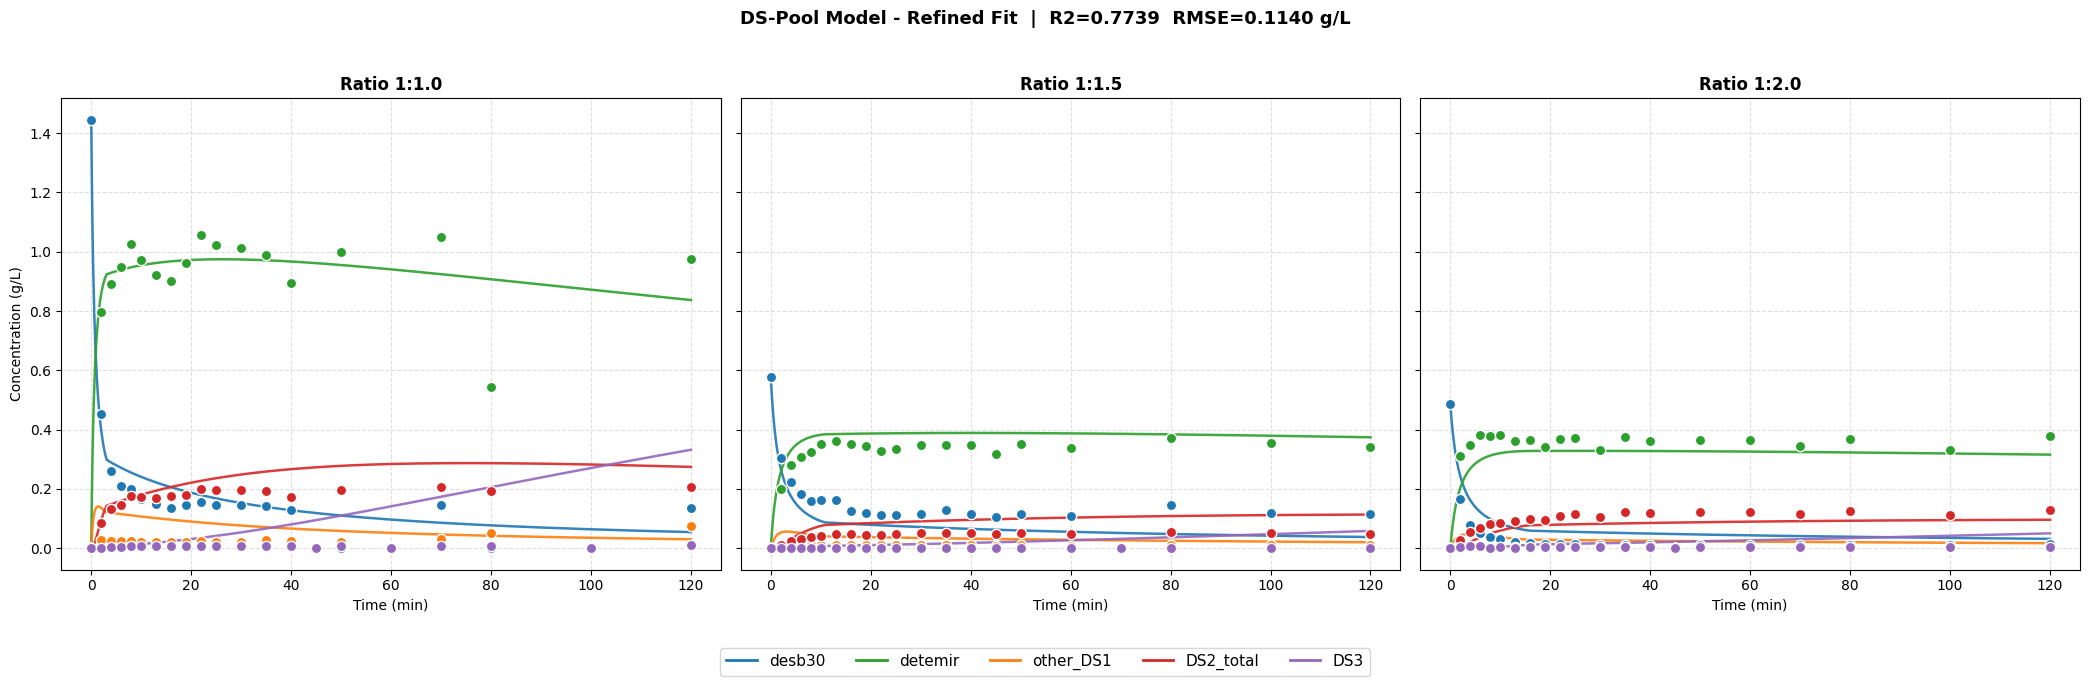

In [10]:
import matplotlib.pyplot as plt

plot_colors = {
    'desb30': '#1f77b4', 'detemir': '#2ca02c',
    'other_DS1': '#ff7f0e', 'DS2_total': '#d62728', 'DS3': '#9467bd'
}

k_vals = results['k_vals']
res_final = results['res_final']
model = DSPoolKineticModel(list(k_vals) + [res_final.x[6], res_final.x[7]])
time_smooth = np.linspace(0, 120, 1000)

fig, axes = plt.subplots(1, len(ratios), figsize=(7 * len(ratios), 6), sharey=True)
if len(ratios) == 1:
    axes = [axes]

for i, r in enumerate(ratios):
    desb30_t0 = experimental_dataset[r]['desb30'][0]
    y0 = np.zeros(len(model.species))
    y0[model.idx['nhs_myr']] = desb30_t0 * r
    y0[model.idx['desb30']] = desb30_t0

    sol_smooth = model.simulate(y0, (0, 120), time_smooth)

    for sp in pool_species_list:
        sim_gL_smooth = sol_smooth.y[model.idx[sp]] * pool_mw[sp]
        exp_gL = experimental_dataset[r][sp] * pool_mw[sp]
        axes[i].plot(time_smooth, sim_gL_smooth, color=plot_colors[sp], linewidth=1.8, alpha=0.9)
        axes[i].scatter(time_exp, exp_gL, color=plot_colors[sp], edgecolors='white',
                         linewidth=1, s=55, zorder=5)

    axes[i].set_title(f"Ratio 1:{r}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Time (min)")
    axes[i].grid(True, linestyle='--', alpha=0.4)

axes[0].set_ylabel("Concentration (g/L)")
dummy_handles = [plt.Line2D([0], [0], color=plot_colors[sp], lw=2) for sp in pool_species_list]
fig.legend(dummy_handles, pool_species_list, loc='upper center', bbox_to_anchor=(0.5, -0.02),
           ncol=5, fontsize=11, frameon=True)
plt.suptitle(f"DS-Pool Model - Refined Fit  |  R2={results['r2']:.4f}  RMSE={results['rmse']:.4f} g/L",
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()
